# KMeans

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

## Data

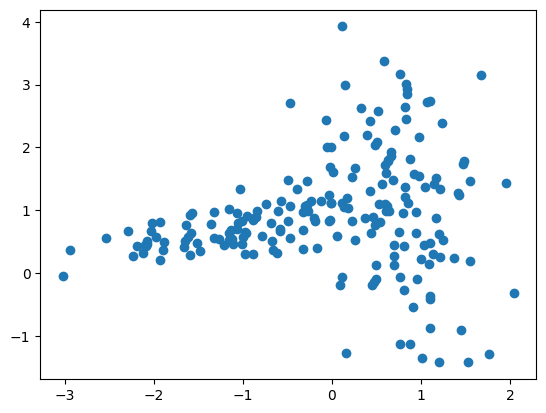

In [ ]:
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

## Centroid initialization

[[ 0.39265381  2.19473735]
 [ 0.17226384  1.19978454]
 [-2.283329    0.66328673]
 [-0.57251587  1.14398268]]


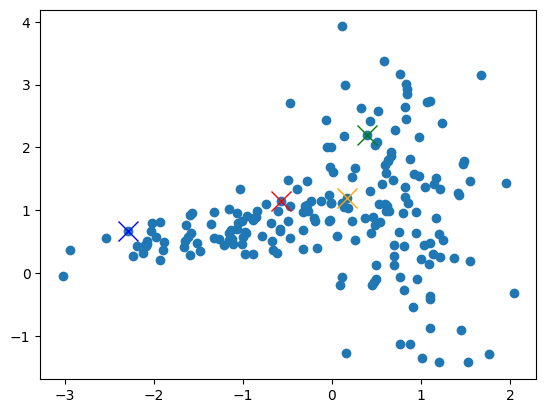

In [48]:
colors = np.array(['green','orange','blue', 'red'])

def plot_points(closest_centroids = None):
    if closest_centroids is None:
        plt.scatter(Xc_2[:,0], Xc_2[:,1])
    else:
        plt.scatter(Xc_2[:,0], Xc_2[:,1], c= colors[closest_centroids])

def init_centroids(amount, is_random = True, points = None, seed = 10): 
    if is_random:
        np.random.seed(seed) 
        return points [np.random.choice(len(points), amount)]        
    
centroids = init_centroids(4, points=Xc_2)
print (centroids)

def plot_centroids(centroids):
    for i, c in enumerate (centroids):
        plt.plot(c[0], c[1], marker = 'x', color= colors[i], markersize=14) 

def draw_state(centroids = None, closest_centroids = None):        
    plt.figure()
    plot_points(closest_centroids)
    plot_centroids(centroids)

draw_state(centroids = centroids, closest_centroids=None)

## Compute distance

In [49]:
def compute_distances(samples, centroids): 
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples-c) for c in centroids])

compute_distances(Xc_2, centroids)

array([[3.35803944, 1.30067989, 0.7631364 , 1.52768169, 2.08835334,
        2.70826807, 0.92353719, 2.36793188, 1.98843551, 0.        ,
        1.11262831, 2.170705  , 0.51387546, 1.14739773, 3.05473757,
        3.08321666, 0.69846075, 2.10805579, 3.04654545, 1.0339453 ,
        2.83850722, 1.85964586, 1.17858787, 1.66606252, 1.8474177 ,
        2.29350499, 1.85314955, 3.70084325, 2.6405407 , 2.6585058 ,
        1.40830809, 2.19171068, 1.80132888, 2.33347575, 2.98147471,
        1.33193831, 3.78899533, 3.04437426, 1.9936611 , 0.86869843,
        4.08113584, 1.41370351, 1.12049863, 3.73554796, 1.64052196,
        2.06458203, 3.1409512 , 1.43917856, 3.59338129, 0.67891403,
        2.4960762 , 2.18110124, 1.16935101, 1.72317515, 0.84404534,
        1.38127857, 3.01199142, 2.31735927, 0.80096651, 1.19930434,
        2.06888203, 1.91227121, 2.29719186, 1.66062031, 1.42675782,
        1.21932275, 1.76209372, 1.06616024, 1.78066176, 3.28043378,
        2.02917811, 0.65553396, 1.80352457, 3.15

## Compute cost

In [50]:
def J(centroids, closest_centroids):
    all_dist = [] 
    for c_index in set(closest_centroids):
        assigned_samples = Xc_2[np.where(closest_centroids==c_index)]
        all_dist_centroid = compute_distances(assigned_samples, [centroids[c_index]])
        all_dist.append(np.sum(all_dist_centroid**2))
    m = len(closest_centroids)
    return 1/m* np.sum(all_dist)


closest_centroids= np.zeros(len(Xc_2), dtype=int) 
print ('Cost= {}'.format(J(centroids, closest_centroids)))

Cost= 3.832381225713059


## Compute closest centroids

closest_centroids:
 [1 3 1 1 3 2 0 3 3 0 1 1 0 1 2 2 1 1 2 0 2 1 1 1 1 1 3 1 2 1 1 3 3 3 2 1 1
 2 3 0 2 3 1 1 1 3 2 3 1 1 1 1 0 3 0 1 2 2 1 0 1 3 1 3 3 3 3 1 3 1 1 1 3 1
 3 3 1 0 0 3 1 3 3 3 0 1 3 0 1 0 2 0 1 0 3 1 1 0 1 0 0 2 1 1 3 2 2 3 3 0 3
 0 2 0 3 1 0 0 3 0 1 0 0 3 1 1 2 0 3 2 1 0 3 3 3 1 1 1 1 1 1 3 1 3 1 1 1 2
 1 2 2 1 3 3 1 3 0 3 1 0 1 3 1 3 2 0 1 0 3 3 1 1 1 1 1 2 3 1 2 3 2 0 0 1 1
 1 1 0 2 1 1 0 2 3 1 0 0 1 3 0]
Cost= 0.955077671274182


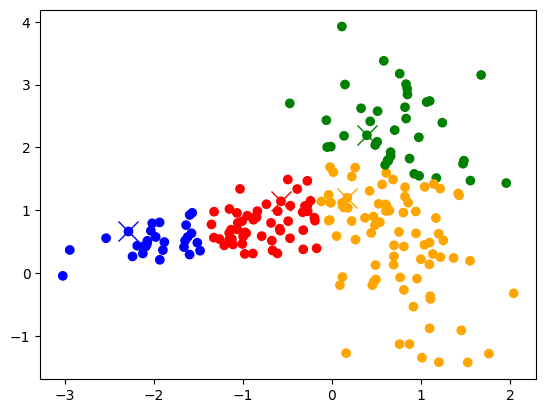

In [51]:
def compute_closest_centroids(centroids):       
    all_distances = compute_distances(Xc_2, centroids)
    closest_centroids = np.apply_along_axis(np.argmin,0,all_distances)
    return closest_centroids

closest_centroids = compute_closest_centroids(centroids) 
print ('closest_centroids:\n',closest_centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))
draw_state(centroids = centroids, closest_centroids = closest_centroids)

## Compute means

New centroids: [array([0.72534103, 2.31032722]), array([0.70911338, 0.50017405]), array([-1.97197565,  0.50964979]), array([-0.76294299,  0.78597559])]
Cost= 0.5593739128795548


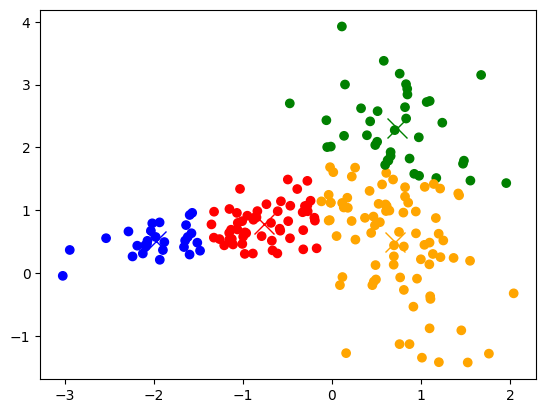

In [52]:
def compute_means(centroids, closest_centroids): 
    new_centroids= []
    for i in range (len(centroids)):
        if i not in closest_centroids:
            new_centroids.append(centroids[i])
        else: 
            new_centroid= np.mean(Xc_2[np.where(closest_centroids==i)], axis = 0)
            new_centroids.append(new_centroid)
    return new_centroids

centroids = compute_means(centroids, closest_centroids)
print ('New centroids:',centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))
draw_state(centroids = centroids, closest_centroids = closest_centroids)

## Cost review

Text(0, 0.5, 'Cost function J')

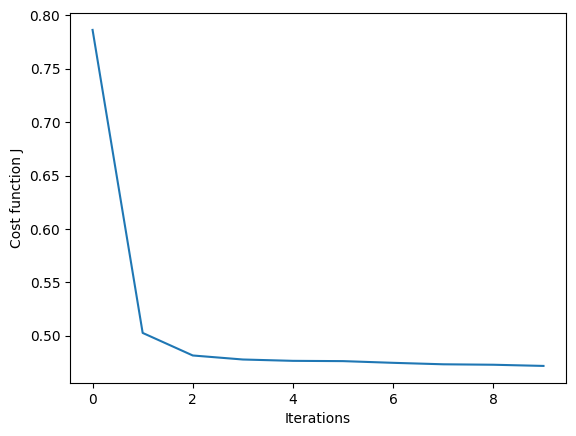

In [53]:
def run_k_means(centroids):
    is_first_time= True 
    J_hist = []
    is_to_continue = True
    
    while is_to_continue:
        closest_centroids = compute_closest_centroids(centroids) 
        centroids = compute_means( centroids , closest_centroids) 
        new_J = J(centroids, closest_centroids)                
        if is_first_time:
            J_hist.append(J(centroids, closest_centroids))            
            is_first_time= False
            continue
        if J_hist[-1] == new_J:
            is_to_continue= False
        else: 
            J_hist.append(J(centroids, closest_centroids))         

    return centroids, closest_centroids, J_hist

centroids= init_centroids(amount = 4, points= Xc_2, seed= None )
centroids, closest_centroids, J_hist = run_k_means(centroids)
plt.figure ()
plt.plot(J_hist)
plt.xlabel('Iterations')
plt.ylabel('Cost function J')



## Random centroid initialization

Iteration # 0, J= 0.46383720396920963
Iteration # 1, J= 0.4576916248652856
Iteration # 2, J= 0.45769162486528564
Iteration # 3, J= 0.4764213287122697
Iteration # 4, J= 0.4638372039692098
Iteration # 5, J= 0.4577585400276276
Iteration # 6, J= 0.4740158254473585
Iteration # 7, J= 0.4764213287122697
Iteration # 8, J= 0.4576916248652856
Iteration # 9, J= 0.462628836683483
Iteration # 10, J= 0.45769162486528564
Iteration # 11, J= 0.4576916248652856
Iteration # 12, J= 0.46396031071245497
Iteration # 13, J= 0.4620437628828036
Iteration # 14, J= 0.4620437628828036
Iteration # 15, J= 0.46383720396920963
Iteration # 16, J= 0.45769162486528564
Iteration # 17, J= 0.45769162486528564
Iteration # 18, J= 0.4622222850704916
Iteration # 19, J= 0.46383720396920974
Iteration # 20, J= 0.45769162486528564
Iteration # 21, J= 0.4620437628828036
Iteration # 22, J= 0.4764213287122697
Iteration # 23, J= 0.4577585400276276
Iteration # 24, J= 0.46383720396920974
Iteration # 25, J= 0.47401582544735854
Iteration # 

Text(0.5, 1.0, 'J=0.458')

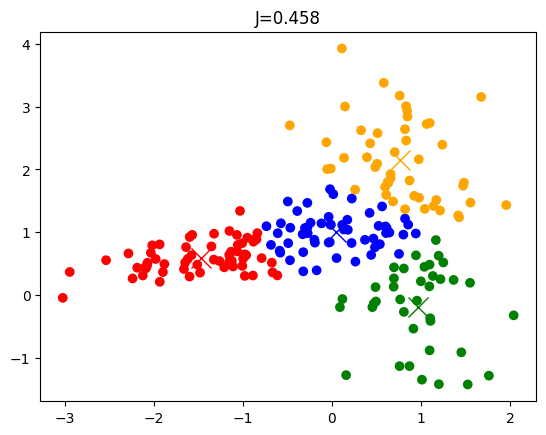

In [54]:
best_result= []

for random_iter in range (100):  
    centroids = init_centroids(amount = 4, points= Xc_2, seed = None)
    centroids, closest_centroids, J_hist = run_k_means(centroids)  
    print ('Iteration # {}, J= {}'.format(random_iter, J_hist[-1]))
    if len(best_result)==0 or J_hist[-1] < best_result[2]:
        best_result= [centroids, closest_centroids, J_hist[-1]]

plt.figure()
plt.scatter(Xc_2[:, 0], Xc_2[:, 1], c= colors[best_result[1]])
for i, c in enumerate (best_result[0]):
    plt.plot(c[0], c[1], marker = 'x', color= colors[i], markersize=14) 
plt.title ('J={:.3f}'.format(best_result[2]))

## Sklearn implementation

J: 0.4581469398652807


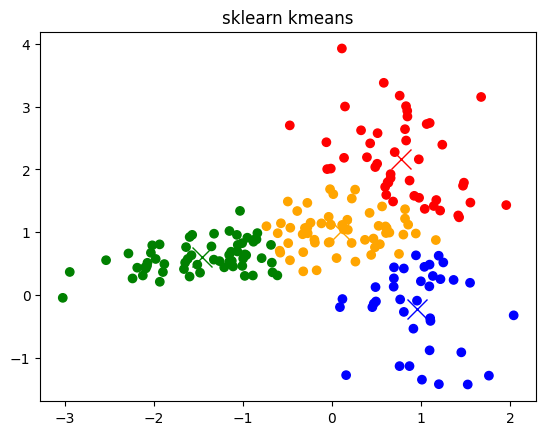

In [57]:
from sklearn.cluster import KMeans
clf = KMeans(n_clusters=4)
clf.fit(Xc_2)
predicted= clf.predict(Xc_2)

plt.figure()

plt.scatter(Xc_2[:, 0], Xc_2[:, 1], c= colors[predicted])

for i, c in enumerate (clf.cluster_centers_):    
    plt.plot(c[0], c[1], marker = 'x', color= colors[i], markersize=14) 
    
plt.title ('sklearn kmeans')
print(f"J: {clf.inertia_ / len(Xc_2)}")